In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, BaggingClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import cohen_kappa_score
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

In [2]:
#File Upload
df=pd.read_csv("bank-additional-full.csv", sep=';')

In [3]:
# 3. Drop Leakage Feature
df.drop('duration', axis=1, inplace=True)

In [4]:
# 4. Handle "unknown" Values
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].replace('unknown', df[col].mode()[0])

In [5]:
# 5. Encode Target
df['y'] = df['y'].map({'no': 0, 'yes': 1})
# 6. One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)
X_shuffled = df.drop('y', axis=1)
y_shuffled = df['y']

In [6]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from scipy.stats import uniform

# Split
X_train, X_test, y_train, y_test = train_test_split(X_shuffled, y_shuffled, test_size=0.2, random_state=42)


In [7]:
# Model
model = LogisticRegression(max_iter=1000)

# Search space
param_dist = {
    "C": uniform(0.01, 10),
    "solver": ["lbfgs", "liblinear"],
    "max_iter": [500, 1000, 2000]
}

In [8]:
# RandomizedSearchCV

random_search = RandomizedSearchCV(model, param_distributions=param_dist, n_iter=50,
                                   cv=5, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_LR = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_LR.score(X_test, y_test)))

Best parameters: {'C': np.float64(6.965160864261275), 'max_iter': 500, 'solver': 'lbfgs'}
Best CV accuracy: 0.9014
Test accuracy: 0.8958


In [9]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
import numpy as np
import pandas as pd
import time

# Define your classifier here (Logistic Regression)
from sklearn.linear_model import LogisticRegression

clf_name = "Logistic Regression"
clf = LogisticRegression(random_state=42, max_iter=1000)



# Store results
results = []

# KFold Cross-Validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=10, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_shuffled)):
    X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]
    y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

    # Train
    start_time = time.time()
    clf.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Predict
    y_pred = clf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    gm = np.sqrt(rec * specificity)
    auc = roc_auc_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Store fold results
    results.append({
        "Fold": fold+1,
        "Classifier": clf_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

# Create DataFrame
results_df = pd.DataFrame(results)

# Print
print(f"Results for {clf_name}:")
print(results_df)

# Save to CSV if needed
results_df.to_csv(f"{clf_name.replace(' ', '_')}_metrics.csv", index=False)

Results for Logistic Regression:
   Fold           Classifier  Accuracy  Precision    Recall  Specificity  \
0     1  Logistic Regression  0.899005   0.649351  0.216450     0.985234   
1     2  Logistic Regression  0.893178   0.615385  0.186047     0.984915   
2     3  Logistic Regression  0.905317   0.707792  0.240088     0.987722   
3     4  Logistic Regression  0.898276   0.643312  0.217672     0.984679   
4     5  Logistic Regression  0.900704   0.642857  0.236324     0.983616   
5     6  Logistic Regression  0.892692   0.680233  0.232143     0.984786   
6     7  Logistic Regression  0.905802   0.647887  0.213953     0.986446   
7     8  Logistic Regression  0.906773   0.688235  0.261161     0.985563   
8     9  Logistic Regression  0.900923   0.691781  0.217672     0.987685   
9    10  Logistic Regression  0.897523   0.709459  0.216942     0.988167   

         F1        GM       FPR       AUC       MCC     Kappa  \
0  0.324675  0.461794  0.014766  0.600842  0.335485  0.284552   


In [10]:
# Model
from sklearn.tree import DecisionTreeClassifier
model1 = DecisionTreeClassifier()

# Search space
param_dist1 = {

    "max_depth":[5,10,20,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

In [11]:
# DecisionTreeClassifier

random_search = RandomizedSearchCV(model1, param_distributions=param_dist1, n_iter=10,
                                   cv=10, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_LR = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_LR.score(X_test, y_test)))

Best parameters: {'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 5}
Best CV accuracy: 0.5640
Test accuracy: 0.8987


In [12]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
import numpy as np
import pandas as pd
import time

# Define your classifier here (Decision Tree)
from sklearn.tree import DecisionTreeClassifier
clf_name = "Decision Tree"
clf = DecisionTreeClassifier()



# Store results
results1 = []

# KFold Cross-Validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=10, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_shuffled)):
    X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]
    y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

    # Train
    start_time = time.time()
    clf.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Predict
    y_pred = clf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    gm = np.sqrt(rec * specificity)
    auc = roc_auc_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Store fold results
    results1.append({
        "Fold": fold+1,
        "Classifier": clf_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

# Create DataFrame
results1_df1 = pd.DataFrame(results1)

# Print
print(f"Results for {clf_name}:")
print(results1_df1)

# Save to CSV if needed
results1_df1.to_csv(f"{clf_name.replace(' ', '_')}_metrics.csv", index=False)

Results for Decision Tree:
   Fold     Classifier  Accuracy  Precision    Recall  Specificity        F1  \
0     1  Decision Tree  0.839767   0.309615  0.348485     0.901832  0.327902   
1     2  Decision Tree  0.839039   0.302083  0.306554     0.908118  0.304302   
2     3  Decision Tree  0.850935   0.326840  0.332599     0.915143  0.329694   
3     4  Decision Tree  0.831755   0.271457  0.293103     0.900137  0.281865   
4     5  Decision Tree  0.837339   0.306715  0.369803     0.895685  0.335317   
5     6  Decision Tree  0.843166   0.360236  0.363095     0.910097  0.361660   
6     7  Decision Tree  0.849478   0.294372  0.316279     0.911629  0.304933   
7     8  Decision Tree  0.845351   0.309091  0.341518     0.906837  0.324496   
8     9  Decision Tree  0.833171   0.292365  0.338362     0.896004  0.313686   
9    10  Decision Tree  0.839242   0.332707  0.365702     0.902312  0.348425   

         GM       FPR       AUC       MCC     Kappa  Balanced Accuracy  \
0  0.560602  0.098

In [13]:
# Model
from sklearn.ensemble import RandomForestClassifier
model2 = RandomForestClassifier()

# Search space
param_dist2 = {
         "n_estimators":[100,200,300],
    "max_depth":[10,20,None],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}

In [14]:
# RandomForestClassifier

random_search = RandomizedSearchCV(model2, param_distributions=param_dist2, n_iter=15,
                                   cv=10, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_LR = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_LR.score(X_test, y_test)))

Best parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10}
Best CV accuracy: 0.6629
Test accuracy: 0.8990



SHAP EXPLANATION STARTED


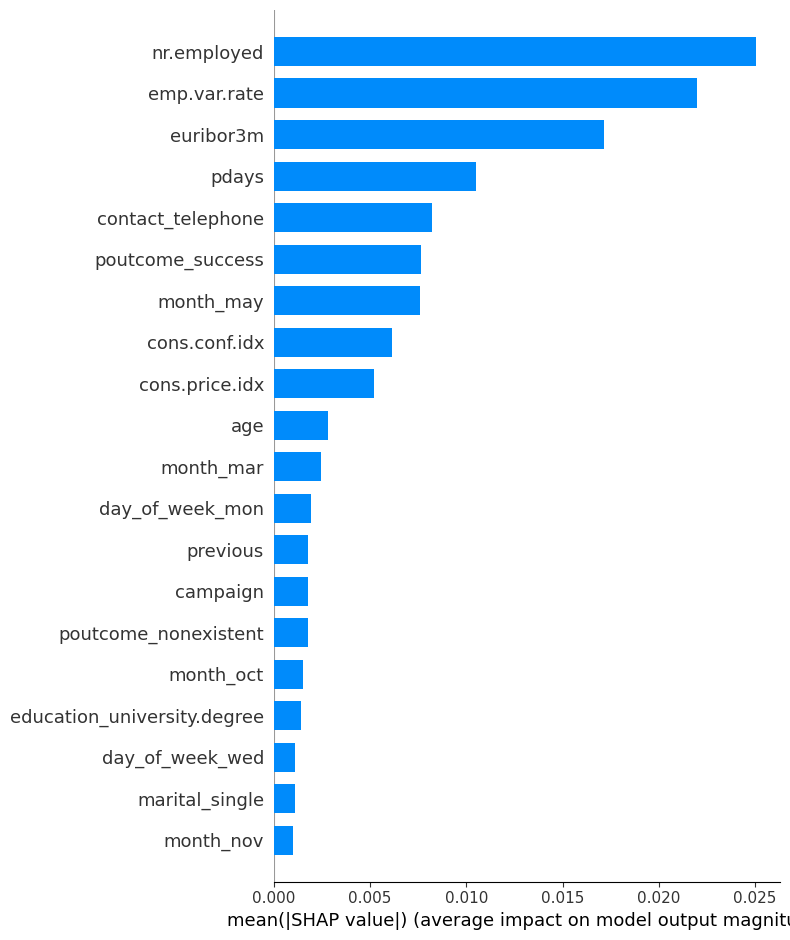

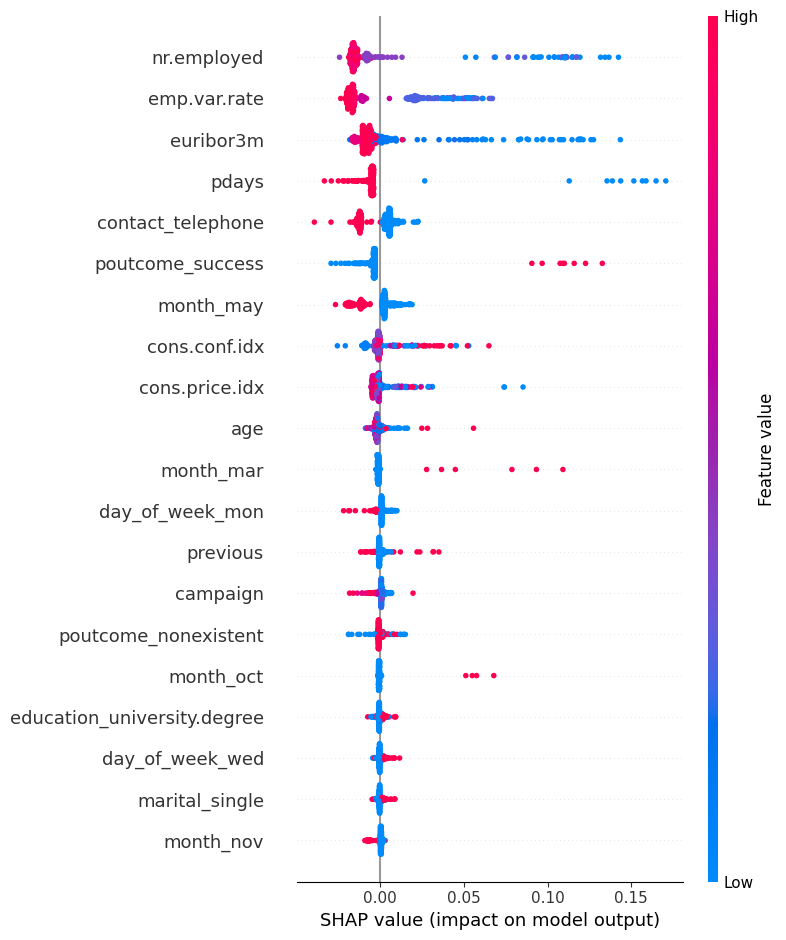

<Figure size 640x480 with 0 Axes>

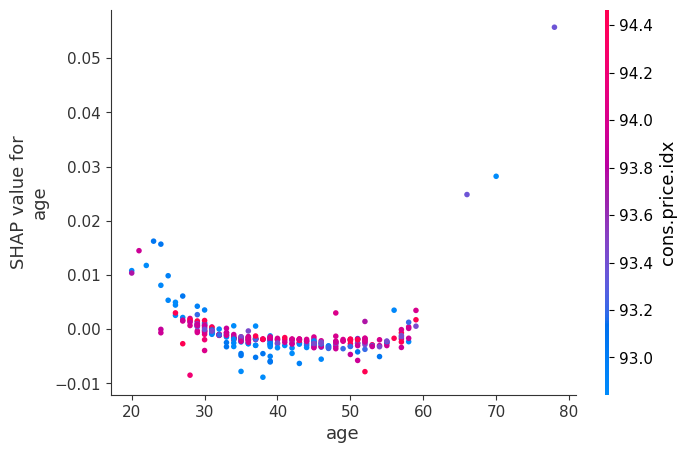

<Figure size 640x480 with 0 Axes>

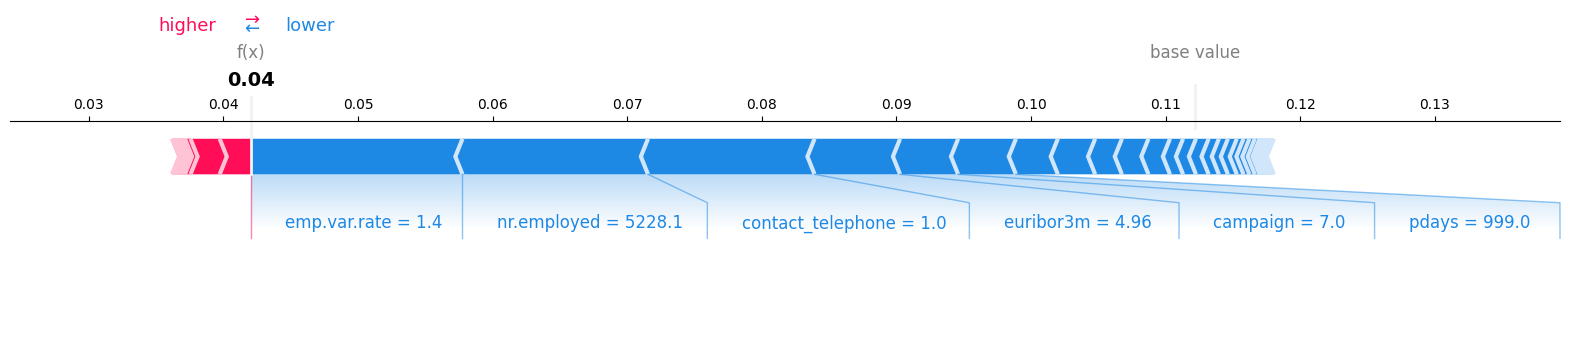

In [15]:
import shap
import matplotlib.pyplot as plt

print("\nSHAP EXPLANATION STARTED")

# take small sample (SHAP slow on full data)
X_sample = X_train.sample(300, random_state=42)

# TreeExplainer for tree models
explainer = shap.TreeExplainer(best_model_LR)

# compute SHAP values
shap_values = explainer.shap_values(X_sample)

# For binary classification -> class 1
shap_vals = shap_values[:,:,1]

#  Global importance (bar)
plt.figure()
shap.summary_plot(shap_vals, X_sample, plot_type="bar", show=False)
plt.savefig("SHAP_Bar.png", bbox_inches="tight")
plt.show()

#  Beeswarm Summary
plt.figure()
shap.summary_plot(shap_vals, X_sample, show=False)
plt.savefig("SHAP_Beeswarm.png", bbox_inches="tight")
plt.show()

#  Dependence Plot
plt.figure()
shap.dependence_plot(X_sample.columns[0], shap_vals, X_sample, show=False)
plt.savefig("SHAP_Dependence.png", bbox_inches="tight")
plt.show()

#  Local Force Plot (STATIC)
plt.figure()
shap.force_plot(
    explainer.expected_value[1],
    shap_vals[0],
    X_sample.iloc[0],
    matplotlib=True,
    show=False
)
plt.savefig("SHAP_Force.png", bbox_inches="tight")
plt.show()


LIME STARTED 
Creating Local LIME...


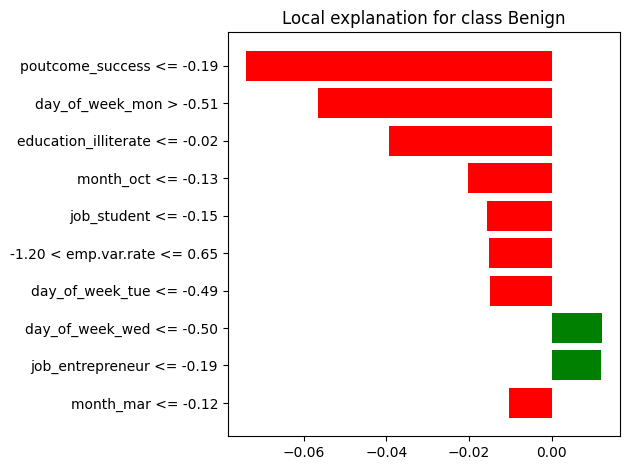

LIME COMPLETED 


In [16]:
from sklearn.preprocessing import StandardScaler
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("LIME STARTED ")

#  SCALE DATA (important for LIME)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


#  CREATE LIME EXPLAINER
lime_explainer = LimeTabularExplainer(
    training_data = X_train_scaled,
    feature_names = X_train.columns.tolist(),
    class_names   = ['Malignant','Benign'],
    mode          = 'classification',
    discretize_continuous = True
)

#  LOCAL LIME (Single Prediction)
print("Creating Local LIME...")

i = 0   # first test row

lime_exp = lime_explainer.explain_instance(
    X_test_scaled[i],
    best_model_LR.predict_proba,
    num_features = 10
)

fig = lime_exp.as_pyplot_figure()
plt.tight_layout()
plt.savefig("LIME_Local_RF.png", dpi=300)
plt.show()
print("LIME COMPLETED ")

In [17]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
import numpy as np
import pandas as pd
import time

# Define your classifier here (Random Forest)
from sklearn.ensemble import RandomForestClassifier
clf_name = "Random Forest"
clf = RandomForestClassifier()



# Store results
results2 = []

# KFold Cross-Validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=10, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_shuffled)):
    X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]
    y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

    # Train
    start_time = time.time()
    clf.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Predict
    y_pred = clf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    gm = np.sqrt(rec * specificity)
    auc = roc_auc_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Store fold results
    results2.append({
        "Fold": fold+1,
        "Classifier": clf_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

# Create DataFrame
results2_df2 = pd.DataFrame(results2)

# Print
print(f"Results for {clf_name}:")
print(results2_df2)

# Save to CSV if needed
results2_df2.to_csv(f"{clf_name.replace(' ', '_')}_metrics.csv", index=False)

Results for Random Forest:
   Fold     Classifier  Accuracy  Precision    Recall  Specificity        F1  \
0     1  Random Forest  0.891964   0.532075  0.305195     0.966092  0.387895   
1     2  Random Forest  0.886866   0.514768  0.257928     0.968459  0.343662   
2     3  Random Forest  0.893421   0.531381  0.279736     0.969441  0.366522   
3     4  Random Forest  0.889536   0.516729  0.299569     0.964432  0.379263   
4     5  Random Forest  0.887594   0.488806  0.286652     0.962589  0.361379   
5     6  Random Forest  0.886137   0.565543  0.299603     0.967911  0.391699   
6     7  Random Forest  0.895849   0.502326  0.251163     0.970995  0.334884   
7     8  Random Forest  0.899490   0.568000  0.316964     0.970580  0.406877   
8     9  Random Forest  0.889267   0.516807  0.265086     0.968528  0.350427   
9    10  Random Forest  0.890238   0.555556  0.330579     0.964777  0.414508   

         GM       FPR       AUC       MCC     Kappa  Balanced Accuracy  \
0  0.542998  0.033

In [18]:
# Model
from sklearn.neighbors import KNeighborsClassifier
model3 = KNeighborsClassifier()

# Search space
param_dist3 = {
         "n_neighbors": [3, 5, 7],
            "weights": ["uniform", "distance"]
}

In [19]:
# KNeighbors Classifier

random_search = RandomizedSearchCV(model3, param_distributions=param_dist3, n_iter=25,
                                   cv=15, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_LR = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_LR.score(X_test, y_test)))

Best parameters: {'weights': 'uniform', 'n_neighbors': 7}
Best CV accuracy: 0.8120
Test accuracy: 0.8919



SHAP EXPLANATION 


100%|██████████| 10/10 [01:44<00:00, 10.43s/it]


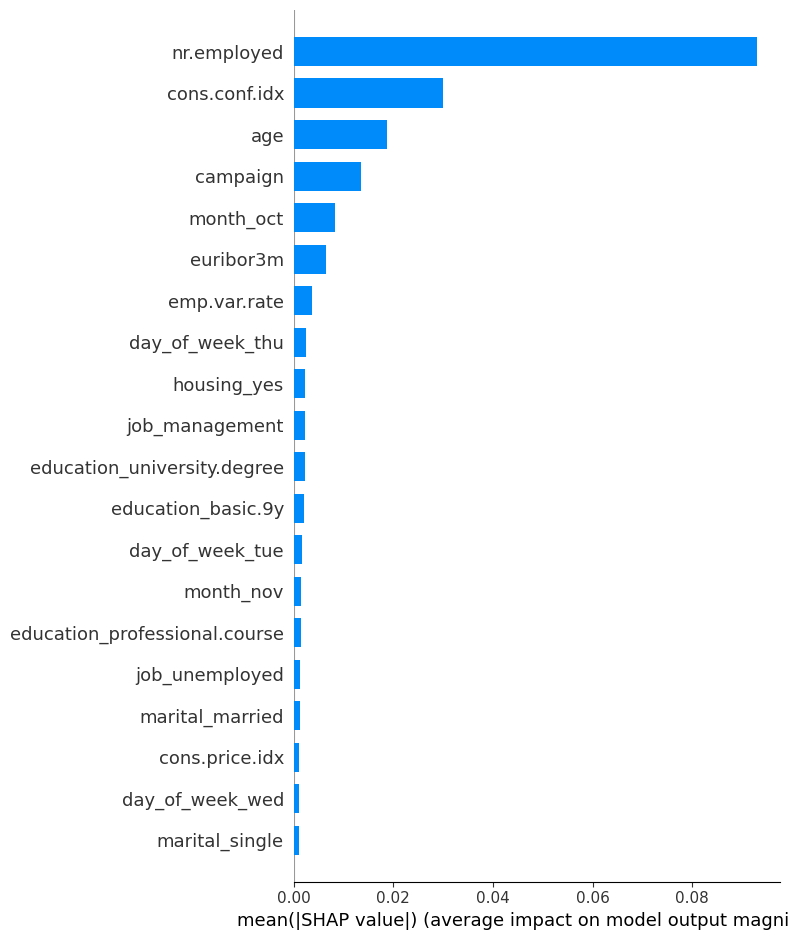

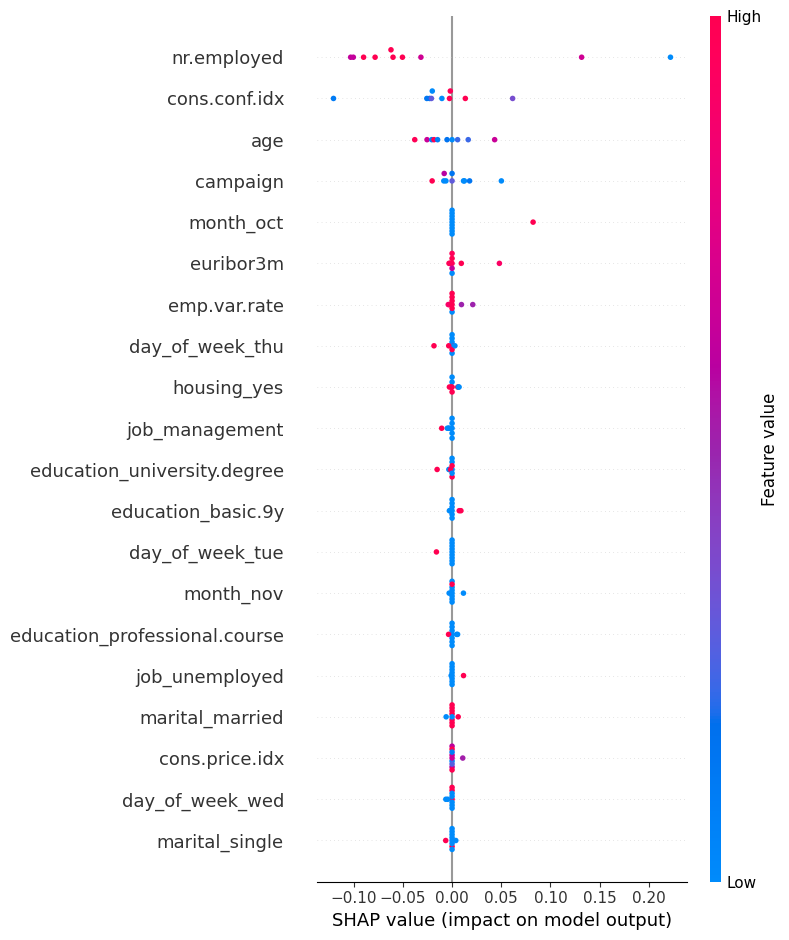

<Figure size 640x480 with 0 Axes>

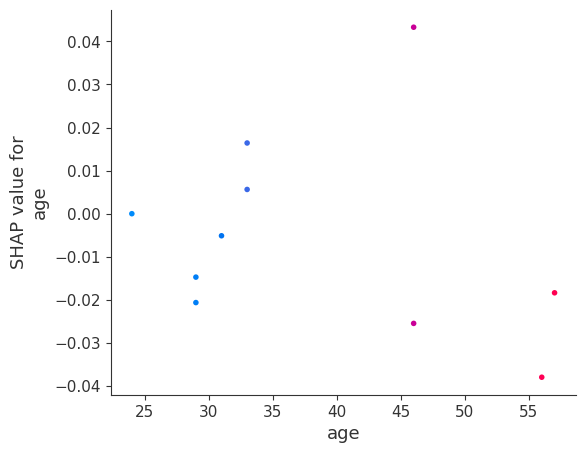

<Figure size 640x480 with 0 Axes>

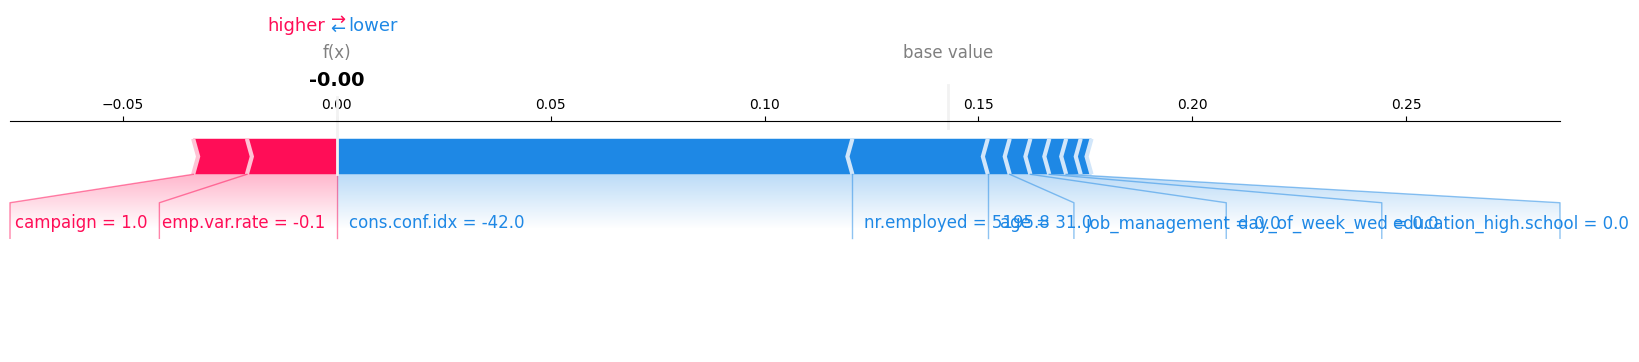

SHAP COMPLETED


In [20]:
import shap
import numpy as np
import matplotlib.pyplot as plt

print("\nSHAP EXPLANATION ")

# SHAP slow → small background
X_sample = X_train.sample(20, random_state=42)
X_test_sample = X_test.sample(10, random_state=42)

# KernelExplainer needs prediction function
def predict_fn(data):
    return best_model_LR.predict_proba(data)

explainer = shap.KernelExplainer(predict_fn, X_sample)

# calculate shap values
shap_values = explainer.shap_values(X_test_sample)

# binary classification → class 1
shap_vals = shap_values[:,:,1]

# Global Feature Importance (BAR)
plt.figure()
shap.summary_plot(shap_vals, X_test_sample, plot_type="bar", show=False)
plt.savefig("KNN_SHAP_bar.png", bbox_inches='tight')
plt.show()

#  Global Beeswarm
plt.figure()
shap.summary_plot(shap_vals, X_test_sample, show=False)
plt.savefig("KNN_SHAP_beeswarm.png", bbox_inches='tight')
plt.show()

#  Dependence Plot
plt.figure()
shap.dependence_plot(X_train.columns[0], shap_vals, X_test_sample, show=False)
plt.savefig("KNN_SHAP_dependence.png", bbox_inches='tight')
plt.show()

# Local Explanation (force plot static)
plt.figure()
shap.force_plot(
    explainer.expected_value[1],
    shap_vals[0],
    X_test_sample.iloc[0],
    matplotlib=True,
    show=False
)
plt.savefig("KNN_SHAP_force.png", bbox_inches='tight')
plt.show()

print("SHAP COMPLETED")


LIME EXPLANATION STARTED

Prediction probability: [[0.71428571 0.28571429]]


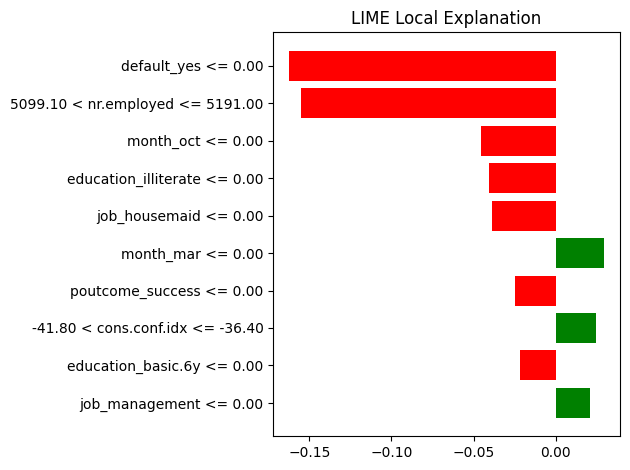


LIME COMPLETED


In [21]:
import lime
import lime.lime_tabular
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")
print("\nLIME EXPLANATION STARTED")

# convert dataframe → numpy (LIME needs numpy)
X_train_np = X_train.values.astype(np.float64)
X_test_np  = X_test.values.astype(np.float64)
scaler=scaler.fit(X_train)
#wrapper for scaled prediction
def predict_fn(x):
    x=np.array(x).astype(float)
    return best_model_LR.predict_proba(x)
# create LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data = X_train_np,
    feature_names = X_train.columns.tolist(),
    class_names   = ["Class 0","Class 1"],   # change if needed
    mode          = "classification",
    discretize_continuous=True,
    sample_around_instance=True
)

#  LOCAL EXPLANATION (single prediction)
i = 0   # choose test sample index

exp = explainer.explain_instance(
    data_row   = X_test_np[i],
    predict_fn = predict_fn,
    num_features=10
)

print("\nPrediction probability:",predict_fn([X_test_np[i]]))

# save static plot (GitHub friendly)
fig = exp.as_pyplot_figure()
plt.title("LIME Local Explanation")
plt.tight_layout()
plt.savefig("LIME_Local_Explanation.png", dpi=300)
plt.show()

print("\nLIME COMPLETED")

In [22]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
import numpy as np
import pandas as pd
import time

# Define your classifier here (KNN)
from sklearn.neighbors import KNeighborsClassifier
clf_name = "KNN"
clf = KNeighborsClassifier()

# Store results
results3 = []




# KFold Cross-Validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=15, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_shuffled)):
    X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]
    y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

    # Train
    start_time = time.time()
    clf.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Predict
    y_pred = clf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    gm = np.sqrt(rec * specificity)
    auc = roc_auc_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Store fold results
    results3.append({
        "Fold": fold+1,
        "Classifier": clf_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

# Create DataFrame
results3_df3 = pd.DataFrame(results3)

# Print
print(f"Results for {clf_name}:")
print(results3_df3)

# Save to CSV if needed
results3_df3.to_csv(f"{clf_name.replace(' ', '_')}_metrics.csv", index=False)

Results for KNN:
    Fold Classifier  Accuracy  Precision    Recall  Specificity        F1  \
0      1        KNN  0.891479   0.564706  0.300000     0.969497  0.391837   
1      2        KNN  0.887473   0.508772  0.278846     0.965489  0.360248   
2      3        KNN  0.887473   0.482558  0.273927     0.963569  0.349474   
3      4        KNN  0.900947   0.608187  0.336570     0.972507  0.433333   
4      5        KNN  0.888929   0.506944  0.237785     0.970890  0.323725   
5      6        KNN  0.893299   0.525140  0.311258     0.965221  0.390852   
6      7        KNN  0.887837   0.448864  0.272414     0.960505  0.339056   
7      8        KNN  0.879097   0.510753  0.282738     0.962241  0.363985   
8      9        KNN  0.886744   0.569767  0.292537     0.969307  0.386588   
9     10        KNN  0.887473   0.484848  0.263158     0.965192  0.341151   
10    11        KNN  0.902403   0.543046  0.291815     0.972008  0.379630   
11    12        KNN  0.894028   0.505208  0.331058     0.96

In [23]:
# Model
from sklearn.svm import LinearSVC
model4 = LinearSVC()



from sklearn.svm import LinearSVC

model4 = LinearSVC()

param_dist4 = {
    "C": [0.01, 0.1, 1, 10],
    "loss": ["hinge", "squared_hinge"],
    "max_iter": [1000, 2000]
}

In [24]:
# LinearSVC

random_search = RandomizedSearchCV(model4, param_distributions=param_dist4, n_iter=10,
                                   cv=10, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_LR = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_LR.score(X_test, y_test)))

Best parameters: {'max_iter': 1000, 'loss': 'hinge', 'C': 0.01}
Best CV accuracy: 0.8682
Test accuracy: 0.8980



  SHAP EXPLANATION 


100%|██████████| 100/100 [03:55<00:00,  2.35s/it]


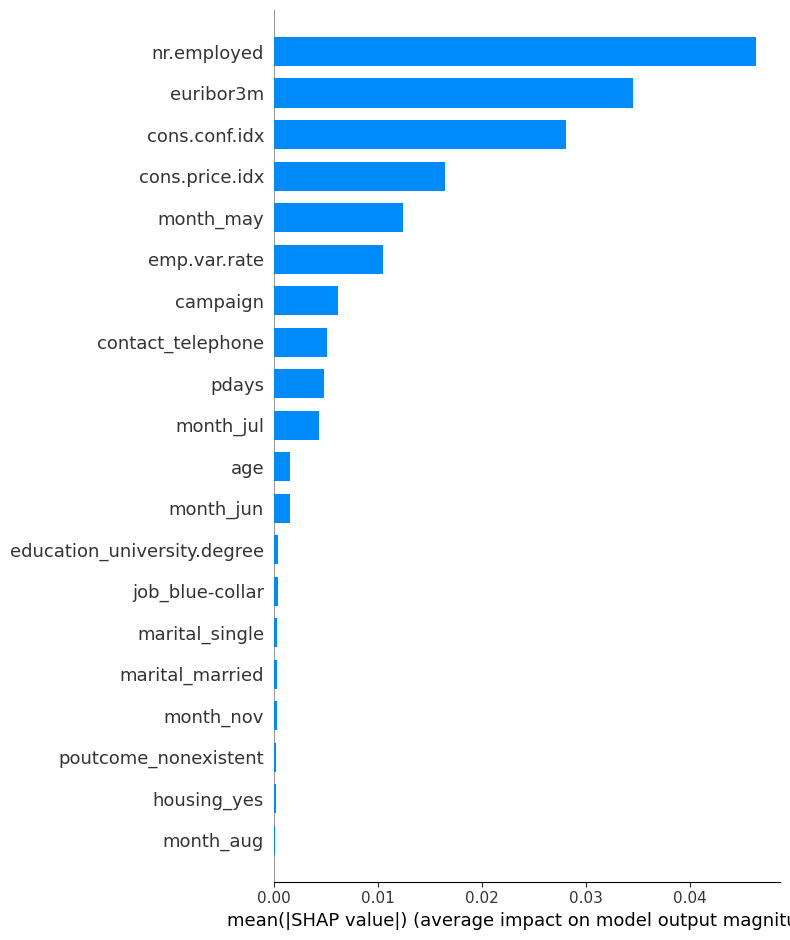

<Figure size 640x480 with 0 Axes>

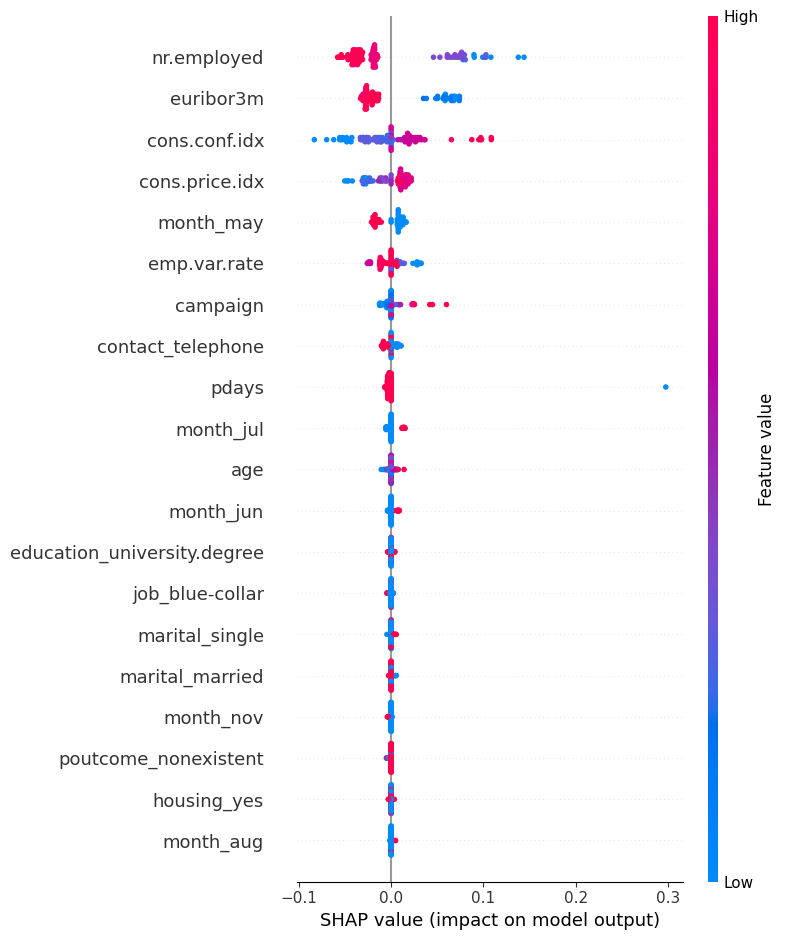

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

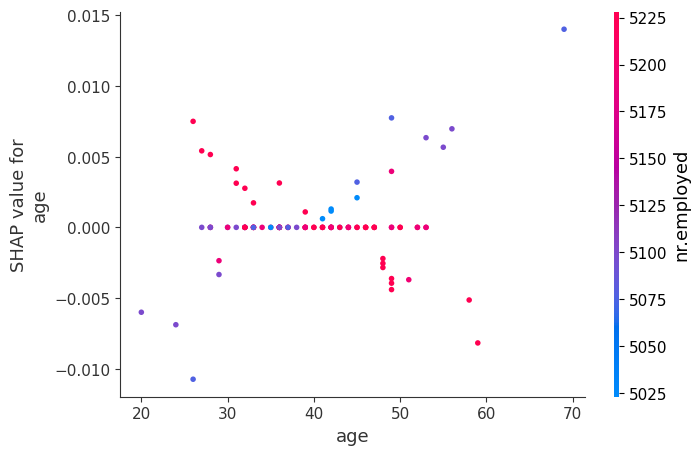

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

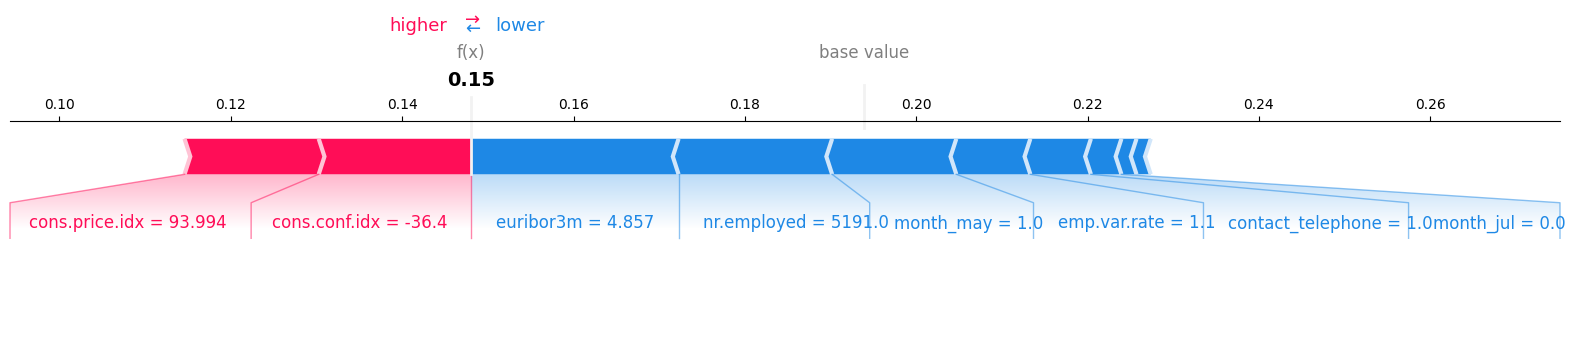

<Figure size 640x480 with 0 Axes>

In [25]:
import shap
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV
print("\n  SHAP EXPLANATION ")
svm = CalibratedClassifierCV(best_model_LR)
svm.fit(X_train,y_train)
X_sample = X_train.sample(100,random_state=42)
# Create KernelExplainer
explainer = shap.KernelExplainer(svm.predict_proba,X_sample)

# Compute SHAP values
shap_values = explainer.shap_values(X_sample)

# For binary classification → explain class 1
shap_vals = shap_values[:,:,1]

# Global Feature Importance
plt.figure()
shap.summary_plot(shap_vals, X_sample, plot_type="bar")
plt.savefig("SHAP_Bar.png", bbox_inches="tight")
plt.show()

#  Detailed Summary Plot
plt.figure()
shap.summary_plot(shap_vals, X_sample)
plt.savefig("SHAP_Beeswarm.png", bbox_inches="tight")
plt.show()

#  Dependence Plot
plt.figure()
shap.dependence_plot(
    X_sample.columns[0],
    shap_vals,
    X_sample
)
plt.savefig("SHAP_Dependence.png", bbox_inches="tight")
plt.show()

#  Force Plot (Single Prediction)

plt.figure()
shap.force_plot(
    explainer.expected_value[1],
    shap_vals[0],
    X_sample.iloc[0],
    matplotlib=True
)
plt.savefig("SHAP_Force.png", bbox_inches="tight")
plt.show()

LIME STARTED 
Model has no predict proba applying calibration .
Creating Local LIME...


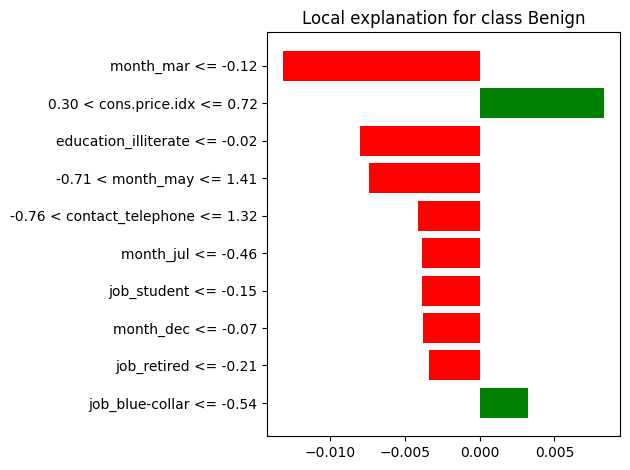

LIME COMPLETED 


In [26]:
from sklearn.preprocessing import StandardScaler
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("LIME STARTED ")
model_lime=best_model_LR
if not hasattr(model_lime,"predict_proba"):
    print("Model has no predict proba applying calibration .")
    model_lime=CalibratedClassifierCV(model_lime,method='sigmoid')
    model_lime.fit(X_train,y_train)
#  SCALE DATA (important for LIME)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


#  CREATE LIME EXPLAINER
lime_explainer = LimeTabularExplainer(
    training_data = X_train_scaled,
    feature_names = X_train.columns.tolist(),
    class_names   = ['Malignant','Benign'],
    mode          = 'classification',
    discretize_continuous = True
)

#  LOCAL LIME (Single Prediction)
print("Creating Local LIME...")

i = 0   # first test row

lime_exp = lime_explainer.explain_instance(
    X_test_scaled[i],
    model_lime.predict_proba,
    num_features = 10
)

fig = lime_exp.as_pyplot_figure()
plt.tight_layout()
plt.savefig("LIME_Local_RF.png", dpi=300)
plt.show()
print("LIME COMPLETED ")

In [27]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
import numpy as np
import pandas as pd
import time

# Define your classifier here (LinearSVC)
from sklearn.svm import LinearSVC
clf_name = "SVM"
clf = LinearSVC()


# Store results
results4 = []



# KFold Cross-Validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=15, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_shuffled)):
    X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]
    y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

    # Train
    start_time = time.time()
    clf.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Predict
    y_pred = clf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    gm = np.sqrt(rec * specificity)
    auc = roc_auc_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Store fold results
    results4.append({
        "Fold": fold+1,
        "Classifier": clf_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

# Create DataFrame
results4_df4 = pd.DataFrame(results4)

# Print
print(f"Results for {clf_name}:")
print(results4_df4)

# Save to CSV if needed
results4_df4.to_csv(f"{clf_name.replace(' ', '_')}_metrics.csv", index=False)

Results for SVM:
    Fold Classifier  Accuracy  Precision    Recall  Specificity        F1  \
0      1        SVM  0.898034   0.712766  0.209375     0.988871  0.323671   
1      2        SVM  0.895849   0.647727  0.182692     0.987264  0.285000   
2      3        SVM  0.897669   0.627907  0.178218     0.986901  0.277635   
3      4        SVM  0.904588   0.747368  0.229773     0.990152  0.351485   
4      5        SVM  0.899490   0.691358  0.182410     0.989750  0.288660   
5      6        SVM  0.900583   0.646465  0.211921     0.985679  0.319202   
6      7        SVM  0.901311   0.602151  0.193103     0.984935  0.292428   
7      8        SVM  0.891843   0.714286  0.193452     0.989212  0.304450   
8      9        SVM  0.894028   0.720000  0.214925     0.988387  0.331034   
9     10        SVM  0.899490   0.652174  0.197368     0.986896  0.303030   
10    11        SVM  0.908230   0.723077  0.167260     0.992698  0.271676   
11    12        SVM  0.907502   0.729412  0.211604     0.99

In [28]:
# Model

from xgboost import XGBClassifier

model5 =  XGBClassifier(use_label_encoder=False, eval_metric='logloss')

param_dist5 = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1],
            "max_depth": [3, 6]
}

In [29]:
# XGBoost

random_search = RandomizedSearchCV(model5, param_distributions=param_dist5, n_iter=100,
                                   cv=20, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_LR = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_LR.score(X_test, y_test)))

Best parameters: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01}
Best CV accuracy: 0.8065
Test accuracy: 0.8944



SHAP EXPLANATION 


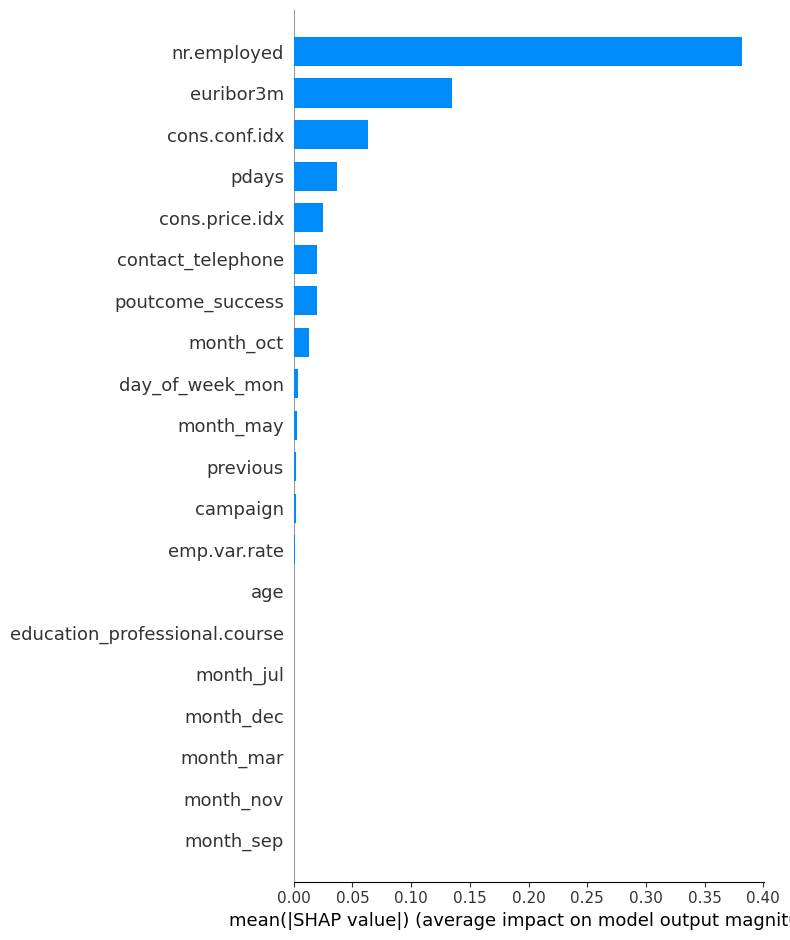

<Figure size 640x480 with 0 Axes>

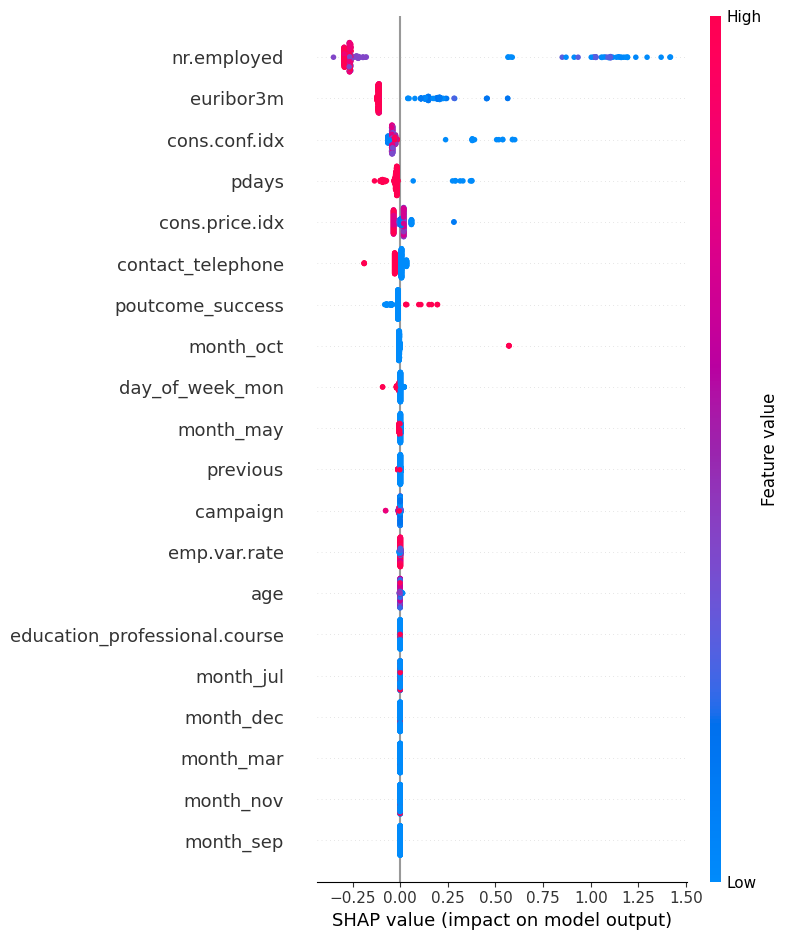

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

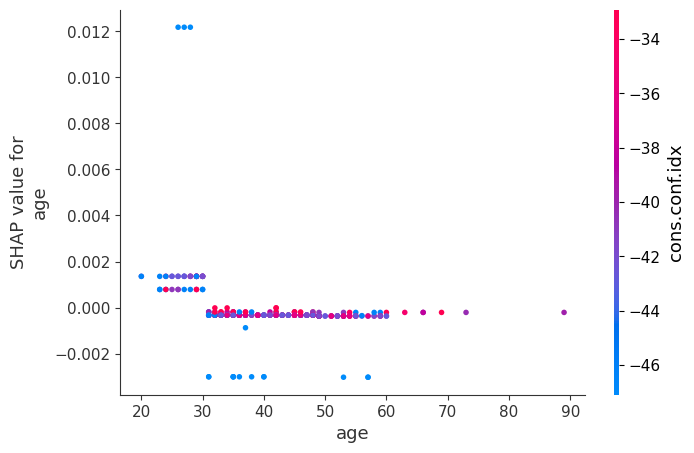

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

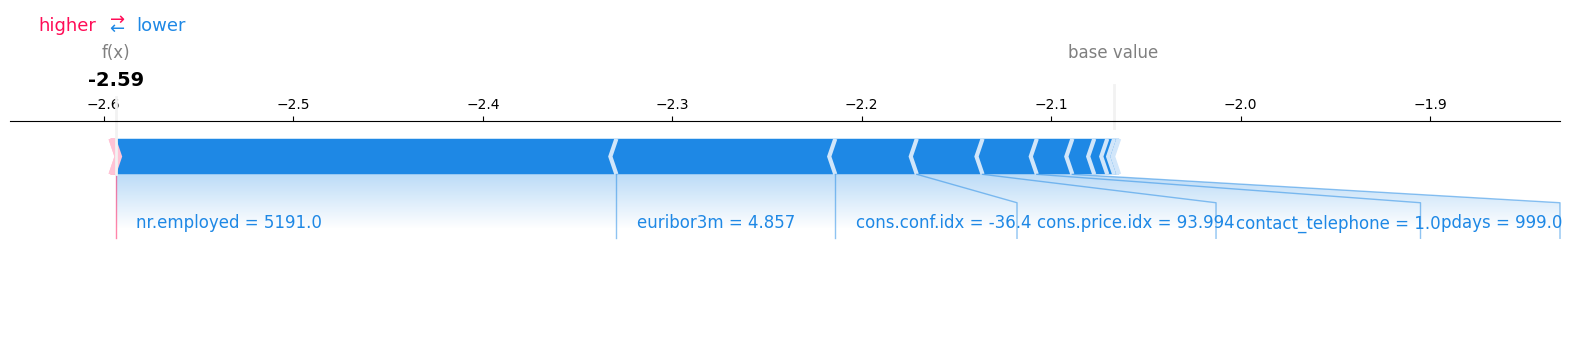

<Figure size 640x480 with 0 Axes>

In [30]:
import shap
import numpy as np
import matplotlib.pyplot as plt

print("\nSHAP EXPLANATION ")

#  take small sample (SHAP is slow on full data)
X_sample = X_train.sample(300, random_state=42)

#  create explainer (new universal method)
explainer = shap.Explainer(best_model_LR)

#  generate SHAP values
shap_values = explainer(X_sample)

#  convert to correct matrix (binary classification → class 1)
if len(shap_values.values.shape)==3:
    shap_vals = shap_values.values[:,:, 1]
else:
    shap_vals = shap_values.values
#  Global Feature Importance (Bar)
plt.figure()
shap.summary_plot(shap_vals, X_sample, plot_type="bar")
plt.savefig("SHAP_Bar.png", bbox_inches="tight")
plt.show()

#  Detailed Beeswarm Summary
plt.figure()
shap.summary_plot(shap_vals, X_sample)
plt.savefig("SHAP_Beeswarm.png", bbox_inches="tight")
plt.show()

#  Dependence Plot
plt.figure()
shap.dependence_plot(
    X_sample.columns[0],
    shap_vals,
    X_sample
)
plt.savefig("SHAP_Dependence.png", bbox_inches="tight")
plt.show()

#  Force Plot (Single Prediction)

plt.figure()
shap.force_plot(
    explainer.expected_value,
    shap_vals[0],
    X_sample.iloc[0],
    matplotlib=True
)
plt.savefig("SHAP_Force.png", bbox_inches="tight")
plt.show()


LIME STARTED 
Creating Local LIME...


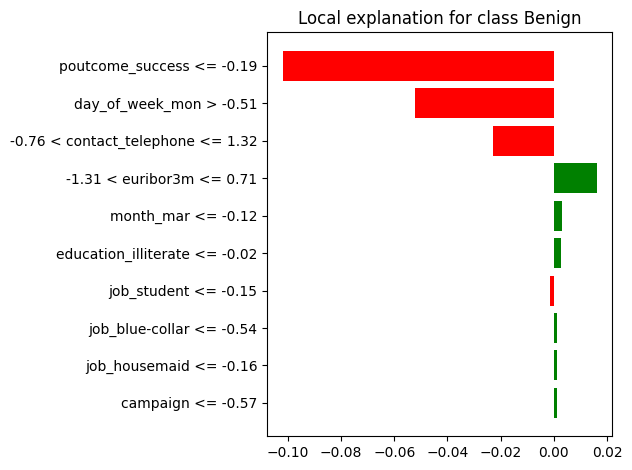

LIME COMPLETED 


In [31]:
from sklearn.preprocessing import StandardScaler
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("LIME STARTED ")

#  SCALE DATA (important for LIME)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


#  CREATE LIME EXPLAINER
lime_explainer = LimeTabularExplainer(
    training_data = X_train_scaled,
    feature_names = X_train.columns.tolist(),
    class_names   = ['Malignant','Benign'],
    mode          = 'classification',
    discretize_continuous = True
)

#  LOCAL LIME (Single Prediction)
print("Creating Local LIME...")

i = 0   # first test row

lime_exp = lime_explainer.explain_instance(
    X_test_scaled[i],
    best_model_LR.predict_proba,
    num_features = 10
)

fig = lime_exp.as_pyplot_figure()
plt.tight_layout()
plt.savefig("LIME_Local_RF.png", dpi=300)
plt.show()

print("LIME COMPLETED ")

In [32]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
import numpy as np
import pandas as pd
import time

# Define your classifier here (XGBoost)
from xgboost import XGBClassifier
clf_name = "XGBoost"
clf =  XGBClassifier(use_label_encoder=False, eval_metric='logloss')


# Store results
results5 = []



# KFold Cross-Validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=15, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_shuffled)):
    X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]
    y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

    # Train
    start_time = time.time()
    clf.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Predict
    y_pred = clf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    gm = np.sqrt(rec * specificity)
    auc = roc_auc_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Store fold results
    results5.append({
        "Fold": fold+1,
        "Classifier": clf_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

# Create DataFrame
results5_df5 = pd.DataFrame(results5)

# Print
print(f"Results for {clf_name}:")
print(results5_df5)

# Save to CSV if needed
results5_df5.to_csv(f"{clf_name.replace(' ', '_')}_metrics.csv", index=False)

Results for XGBoost:
    Fold Classifier  Accuracy  Precision    Recall  Specificity        F1  \
0      1    XGBoost  0.890386   0.559748  0.278125     0.971146  0.371608   
1      2    XGBoost  0.891843   0.551020  0.259615     0.972884  0.352941   
2      3    XGBoost  0.896941   0.571429  0.264026     0.975440  0.361174   
3      4    XGBoost  0.904953   0.671429  0.304207     0.981124  0.418708   
4      5    XGBoost  0.901311   0.625000  0.293160     0.977860  0.399113   
5      6    XGBoost  0.898034   0.568750  0.301325     0.971768  0.393939   
6      7    XGBoost  0.895484   0.509804  0.268966     0.969463  0.352144   
7      8    XGBoost  0.889658   0.610738  0.270833     0.975934  0.375258   
8      9    XGBoost  0.886016   0.572368  0.259701     0.973040  0.357290   
9     10    XGBoost  0.898034   0.593750  0.250000     0.978706  0.351852   
10    11    XGBoost  0.906409   0.592308  0.274021     0.978499  0.374696   
11    12    XGBoost  0.907138   0.631944  0.310580     

In [33]:
# Model LightGBM

model6 =  LGBMClassifier()

param_dist6 = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1]
}

In [34]:
# LightGBM

random_search = RandomizedSearchCV(model6, param_distributions=param_dist6, n_iter=100,
                                   cv=25, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_LR = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_LR.score(X_test, y_test)))

[LightGBM] [Info] Number of positive: 4327, number of negative: 34116
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002693 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 492
[LightGBM] [Info] Number of data points in the train set: 38443, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112556 -> initscore=-2.064892
[LightGBM] [Info] Start training from score -2.064892
Best parameters: {'n_estimators': 100, 'learning_rate': 0.01}
Best CV accuracy: 0.6616
Test accuracy: 0.8947



SHAP EXPLANATION 


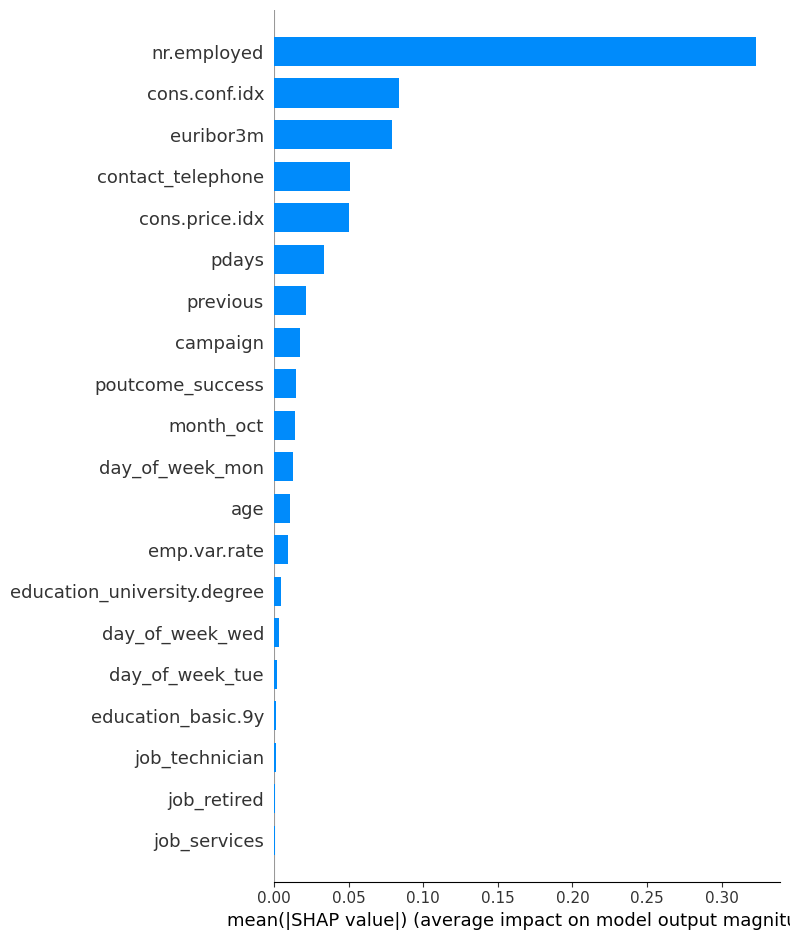

<Figure size 640x480 with 0 Axes>

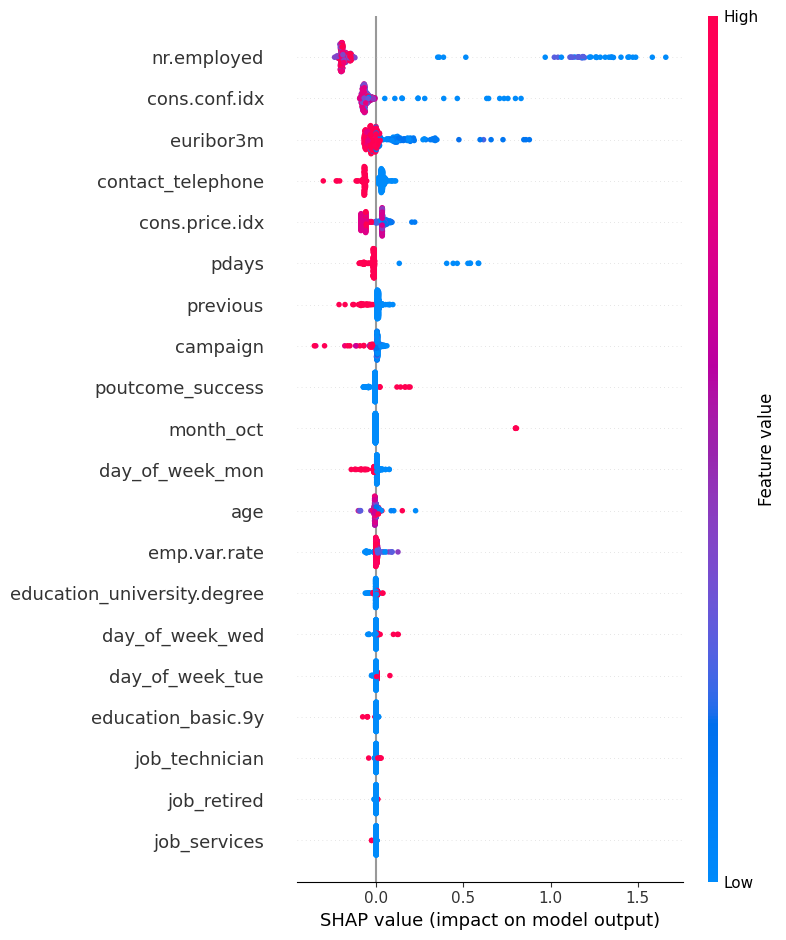

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

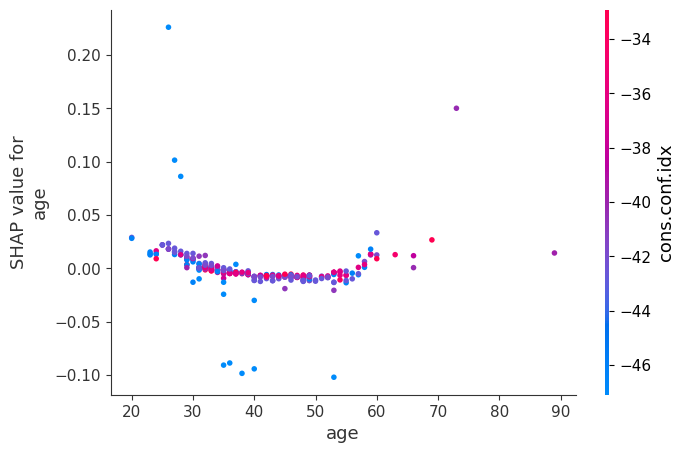

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

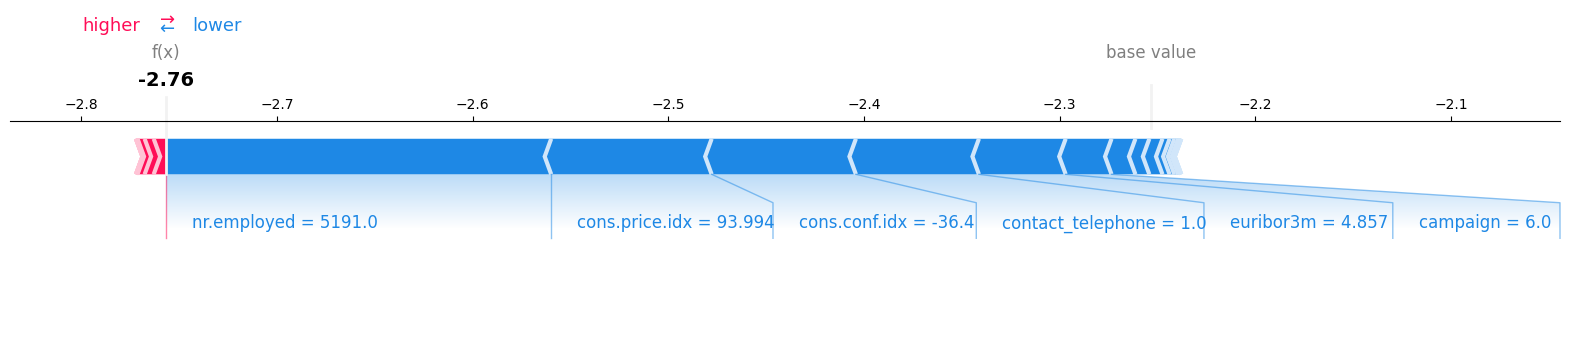

<Figure size 640x480 with 0 Axes>

In [35]:
import shap
import numpy as np
import matplotlib.pyplot as plt

print("\nSHAP EXPLANATION ")

#  take small sample (SHAP is slow on full data)
X_sample = X_train.sample(300, random_state=42)

#  create explainer (new universal method)
explainer = shap.Explainer(best_model_LR)

#  generate SHAP values
shap_values = explainer(X_sample)

#  convert to correct matrix (binary classification → class 1)
if len(shap_values.values.shape)==3:
    shap_vals = shap_values.values[:,:, 1]
else:
    shap_vals = shap_values.values
#  Global Feature Importance (Bar)
plt.figure()
shap.summary_plot(shap_vals, X_sample, plot_type="bar")
plt.savefig("SHAP_Bar.png", bbox_inches="tight")
plt.show()

#  Detailed Beeswarm Summary
plt.figure()
shap.summary_plot(shap_vals, X_sample)
plt.savefig("SHAP_Beeswarm.png", bbox_inches="tight")
plt.show()

#  Dependence Plot
plt.figure()
shap.dependence_plot(
    X_sample.columns[0],
    shap_vals,
    X_sample
)
plt.savefig("SHAP_Dependence.png", bbox_inches="tight")
plt.show()

#  Force Plot (Single Prediction)
plt.figure()
shap.force_plot(
    explainer.expected_value,
    shap_vals[0],
    X_sample.iloc[0],
    matplotlib=True
)
plt.savefig("SHAP_Force.png", bbox_inches="tight")
plt.show()

LIME STARTED 
Creating Local LIME...


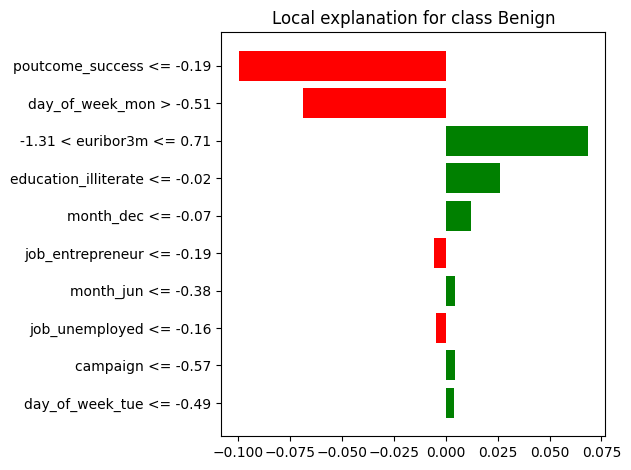

LIME COMPLETED 


In [36]:
from sklearn.preprocessing import StandardScaler
from lime.lime_tabular import LimeTabularExplainer
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("LIME STARTED ")

#  SCALE DATA (important for LIME)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


#  CREATE LIME EXPLAINER
lime_explainer = LimeTabularExplainer(
    training_data = X_train_scaled,
    feature_names = X_train.columns.tolist(),
    class_names   = ['Malignant','Benign'],
    mode          = 'classification',
    discretize_continuous = True
)

#  LOCAL LIME (Single Prediction)
print("Creating Local LIME...")

i = 0   # first test row

lime_exp = lime_explainer.explain_instance(
    X_test_scaled[i],
    best_model_LR.predict_proba,
    num_features = 10
)

fig = lime_exp.as_pyplot_figure()
plt.tight_layout()
plt.savefig("LIME_Local_RF.png", dpi=300)
plt.show()

print("LIME COMPLETED ")

In [37]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
import numpy as np
import pandas as pd
import time

# Define your classifier here (XGBoost)
from lightgbm import LGBMClassifier
clf_name = "LightGBM"
clf =  LGBMClassifier()


# Store results
results6 = []



# KFold Cross-Validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=15, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_shuffled)):
    X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]
    y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

    # Train
    start_time = time.time()
    clf.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Predict
    y_pred = clf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    gm = np.sqrt(rec * specificity)
    auc = roc_auc_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Store fold results
    results6.append({
        "Fold": fold+1,
        "Classifier": clf_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

# Create DataFrame
results6_df6 = pd.DataFrame(results6)

# Print
print(f"Results for {clf_name}:")
print(results6_df6)

# Save to CSV if needed
results6_df6.to_csv(f"{clf_name.replace(' ', '_')}_metrics.csv", index=False)

[LightGBM] [Info] Number of positive: 4320, number of negative: 34122
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003559 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 493
[LightGBM] [Info] Number of data points in the train set: 38442, number of used features: 44
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112377 -> initscore=-2.066687
[LightGBM] [Info] Start training from score -2.066687
[LightGBM] [Info] Number of positive: 4328, number of negative: 34114
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003547 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 493
[LightGBM] [Info] Number of data points in the train set: 38442, number of used features: 44
[LightGBM] [Info] [bin

In [38]:
# Model CatBoost

from catboost import CatBoostClassifier

model7 =   CatBoostClassifier(verbose=0)

param_dist7 = {
     "iterations": [100, 200],
     "depth": [4, 6],
     "learning_rate": [0.01, 0.1]
}

In [39]:
# CatBoost

random_search = RandomizedSearchCV(model7, param_distributions=param_dist7, n_iter=25,
                                   cv=30, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_LR = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_LR.score(X_test, y_test)))

Best parameters: {'learning_rate': 0.01, 'iterations': 100, 'depth': 4}
Best CV accuracy: 0.8470
Test accuracy: 0.8980


In [40]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
import numpy as np
import pandas as pd
import time

# Define your classifier here (CatBoost)
from catboost import CatBoostClassifier
clf_name = "CatBoost"
clf =   CatBoostClassifier(iterations=20, verbose=0)


# Store results
results7 = []



# KFold Cross-Validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=15, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_shuffled)):
    X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]
    y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

    # Train
    start_time = time.time()
    clf.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Predict
    y_pred = clf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    gm = np.sqrt(rec * specificity)
    auc = roc_auc_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Store fold results
    results7.append({
        "Fold": fold+1,
        "Classifier": clf_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

# Create DataFrame
results7_df7 = pd.DataFrame(results7)

# Print
print(f"Results for {clf_name}:")
print(results7_df7)

# Save to CSV if needed
results7_df7.to_csv(f"{clf_name.replace(' ', '_')}_metrics.csv", index=False)

Results for CatBoost:
    Fold Classifier  Accuracy  Precision    Recall  Specificity        F1  \
0      1   CatBoost  0.896941   0.627586  0.284375     0.977741  0.391398   
1      2   CatBoost  0.895849   0.614035  0.224359     0.981923  0.328638   
2      3   CatBoost  0.899490   0.613445  0.240924     0.981171  0.345972   
3      4   CatBoost  0.907502   0.709924  0.300971     0.984407  0.422727   
4      5   CatBoost  0.900218   0.643478  0.241042     0.983190  0.350711   
5      6   CatBoost  0.899490   0.601562  0.254967     0.979133  0.358140   
6      7   CatBoost  0.898762   0.543478  0.258621     0.974349  0.350467   
7      8   CatBoost  0.896941   0.719008  0.258929     0.985892  0.380744   
8      9   CatBoost  0.891479   0.627586  0.271642     0.977603  0.379167   
9     10   CatBoost  0.902039   0.644628  0.256579     0.982391  0.367059   
10    11   CatBoost  0.908594   0.638889  0.245552     0.984178  0.354756   
11    12   CatBoost  0.907502   0.653543  0.283276    

In [41]:
# Model Gradient Boosting

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier, StackingClassifier

model8 =   GradientBoostingClassifier(n_estimators=25)

param_dist8 = {
      "learning_rate": [0.1, 0.3,0.6],
      "n_estimators": [50, 100],
}

In [42]:
# Gradient Boosting

random_search = RandomizedSearchCV(model8, param_distributions=param_dist8, n_iter=5,
                                   cv=30, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_LR = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_LR.score(X_test, y_test)))

Best parameters: {'n_estimators': 50, 'learning_rate': 0.1}
Best CV accuracy: 0.7781
Test accuracy: 0.8976


In [43]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
import numpy as np
import pandas as pd
import time

# Define your classifier here (Gradient Boosting)
from sklearn.ensemble import  GradientBoostingClassifier

clf_name = "Gradient Boosting"
clf =    GradientBoostingClassifier()


# Store results
results8 = []



# KFold Cross-Validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=15, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_shuffled)):
    X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]
    y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

    # Train
    start_time = time.time()
    clf.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Predict
    y_pred = clf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    gm = np.sqrt(rec * specificity)
    auc = roc_auc_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Store fold results
    results8.append({
        "Fold": fold+1,
        "Classifier": clf_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

# Create DataFrame
results8_df8= pd.DataFrame(results8)

# Print
print(f"Results for {clf_name}:")
print(results8_df8)

# Save to CSV if needed
results8_df8.to_csv(f"{clf_name.replace(' ', '_')}_metrics.csv", index=False)

Results for Gradient Boosting:
    Fold         Classifier  Accuracy  Precision    Recall  Specificity  \
0      1  Gradient Boosting  0.896941   0.637037  0.268750     0.979802   
1      2  Gradient Boosting  0.894756   0.605505  0.211538     0.982334   
2      3  Gradient Boosting  0.900947   0.632479  0.244224     0.982399   
3      4  Gradient Boosting  0.904953   0.706897  0.265372     0.986048   
4      5  Gradient Boosting  0.904224   0.703704  0.247557     0.986880   
5      6  Gradient Boosting  0.903132   0.642857  0.268212     0.981588   
6      7  Gradient Boosting  0.903860   0.600000  0.268966     0.978827   
7      8  Gradient Boosting  0.895120   0.700000  0.250000     0.985062   
8      9  Gradient Boosting  0.895484   0.676471  0.274627     0.981750   
9     10  Gradient Boosting  0.904588   0.690909  0.250000     0.986077   
10    11  Gradient Boosting  0.908594   0.653061  0.227758     0.986207   
11    12  Gradient Boosting  0.908958   0.677686  0.279863     0.9841

In [44]:
# Model MLP

from sklearn.neural_network import MLPClassifier
model9 =   MLPClassifier(max_iter=300)
param_dist9 = {
      "hidden_layer_sizes": [(64,64), (128,64)]
}

In [45]:
# MLP

random_search = RandomizedSearchCV(model9, param_distributions=param_dist9, n_iter=300,
                                   cv=30, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_LR = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_LR.score(X_test, y_test)))

Best parameters: {'hidden_layer_sizes': (64, 64)}
Best CV accuracy: 0.8549
Test accuracy: 0.8922


In [46]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
import numpy as np
import pandas as pd
import time

# Define your classifier here (MLP)
from sklearn.neural_network import MLPClassifier
clf_name = "MLP"
clf =   MLPClassifier(max_iter=500)


# Store results
results9 = []



# KFold Cross-Validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=15, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_shuffled)):
    X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]
    y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

    # Train
    start_time = time.time()
    clf.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Predict
    y_pred = clf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    gm = np.sqrt(rec * specificity)
    auc = roc_auc_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Store fold results
    results9.append({
        "Fold": fold+1,
        "Classifier": clf_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

# Create DataFrame
results9_df9= pd.DataFrame(results9)

# Print
print(f"Results for {clf_name}:")
print(results9_df9)

# Save to CSV if needed
results9_df9.to_csv(f"{clf_name.replace(' ', '_')}_metrics.csv", index=False)

Results for MLP:
    Fold Classifier  Accuracy  Precision    Recall  Specificity        F1  \
0      1        MLP  0.885652   0.516129  0.300000     0.962902  0.379447   
1      2        MLP  0.886380   0.000000  0.000000     1.000000  0.000000   
2      3        MLP  0.894756   0.570000  0.188119     0.982399  0.282878   
3      4        MLP  0.900583   0.657895  0.242718     0.983997  0.354610   
4      5        MLP  0.896577   0.618557  0.195440     0.984830  0.297030   
5      6        MLP  0.899490   0.618182  0.225166     0.982815  0.330097   
6      7        MLP  0.894392   0.000000  0.000000     1.000000  0.000000   
7      8        MLP  0.878369   0.750000  0.008929     0.999585  0.017647   
8      9        MLP  0.881282   1.000000  0.026866     1.000000  0.052326   
9     10        MLP  0.899490   0.642857  0.207237     0.985667  0.313433   
10    11        MLP  0.904953   0.631579  0.170819     0.988641  0.268908   
11    12        MLP  0.682083   0.223282  0.798635     0.66

In [47]:
# Model Bagging
from sklearn.ensemble import BaggingClassifier
model10 =   BaggingClassifier(n_estimators=10)
param_dist10 = {
     "n_estimators": [50, 100]
}

In [48]:
# BaggingClassifier

random_search = RandomizedSearchCV(model10, param_distributions=param_dist10, n_iter=500,
                                   cv=30, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_LR = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_LR.score(X_test, y_test)))

Best parameters: {'n_estimators': 100}
Best CV accuracy: 0.4748
Test accuracy: 0.8874


In [49]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
import numpy as np
import pandas as pd
import time

# Define your classifier here (BaggingClassifier)
from sklearn.ensemble import BaggingClassifier
clf_name = "BaggingClassifier"
clf =   BaggingClassifier(n_estimators=10)


# Store results
results10 = []



# KFold Cross-Validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=25, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_shuffled)):
    X_train, X_test = X_shuffled.iloc[train_idx], X_shuffled.iloc[test_idx]
    y_train, y_test = y_shuffled.iloc[train_idx], y_shuffled.iloc[test_idx]

    # Train
    start_time = time.time()
    clf.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Predict
    y_pred = clf.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    gm = np.sqrt(rec * specificity)
    auc = roc_auc_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Store fold results
    results10.append({
        "Fold": fold+1,
        "Classifier": clf_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

# Create DataFrame
results10_df10= pd.DataFrame(results10)

# Print
print(f"Results for {clf_name}:")
print(results10_df10)

# Save to CSV if needed
results10_df10.to_csv(f"{clf_name.replace(' ', '_')}_metrics.csv", index=False)

Results for BaggingClassifier:
    Fold         Classifier  Accuracy  Precision    Recall  Specificity  \
0      1  BaggingClassifier  0.885316   0.504274  0.310526     0.960219   
1      2  BaggingClassifier  0.893204   0.544000  0.363636     0.960986   
2      3  BaggingClassifier  0.890170   0.474227  0.261364     0.965353   
3      4  BaggingClassifier  0.877427   0.458333  0.226804     0.964237   
4      5  BaggingClassifier  0.869539   0.382609  0.234043     0.951370   
5      6  BaggingClassifier  0.891990   0.525773  0.278689     0.968601   
6      7  BaggingClassifier  0.893811   0.524752  0.294444     0.967302   
7      8  BaggingClassifier  0.881068   0.485437  0.259067     0.963574   
8      9  BaggingClassifier  0.887743   0.462185  0.312500     0.956522   
9     10  BaggingClassifier  0.879854   0.446429  0.268817     0.957592   
10    11  BaggingClassifier  0.885922   0.457143  0.268156     0.961198   
11    12  BaggingClassifier  0.883495   0.417476  0.245714     0.9592

In [78]:
# RandomForestClassifier

random_search = RandomizedSearchCV(model2, param_distributions=param_dist2, n_iter=15,
                                   cv=10, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_rf = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_rf.score(X_test, y_test)))

Best parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10}
Best CV accuracy: 0.6672
Test accuracy: 0.9017


In [79]:
# KNeighbors Classifier

random_search = RandomizedSearchCV(model3, param_distributions=param_dist3, n_iter=25,
                                   cv=15, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_knn = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_knn.score(X_test, y_test)))

Best parameters: {'weights': 'uniform', 'n_neighbors': 7}
Best CV accuracy: 0.8094
Test accuracy: 0.8875


In [80]:
# LinearSVC

random_search = RandomizedSearchCV(model4, param_distributions=param_dist4, n_iter=10,
                                   cv=10, scoring="accuracy", random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_model_svm = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_svm.score(X_test, y_test)))

Best parameters: {'max_iter': 2000, 'loss': 'hinge', 'C': 10}
Best CV accuracy: 0.8725
Test accuracy: 0.8420


In [100]:
from sklearn.ensemble import StackingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# FAST base models
hgb = HistGradientBoostingClassifier(
    max_iter=100,      
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC())   
])

lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000))
])

# Stacking model
stack_model = StackingClassifier(
    estimators=[
        ("hgb", hgb),
        ("svm", svm),
        ("lr", lr)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=3,           
    n_jobs=-1,
    passthrough=True
)

In [101]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "final_estimator__C": [0.01, 0.1, 1, 5, 10],
    "final_estimator__penalty": ["l2"]
}

random_search = RandomizedSearchCV(
    estimator=stack_model,
    param_distributions=param_grid,
    n_iter=3,      
    cv=3,          
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_shuffled, y_shuffled)

best_model_stack = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)
print("Best CV accuracy: {:.4f}".format(random_search.best_score_))
print("Test accuracy: {:.4f}".format(best_model_stack.score(X_test, y_test)))

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best parameters: {'final_estimator__penalty': 'l2', 'final_estimator__C': 1}
Best CV accuracy: 0.5107
Test accuracy: 0.7359


In [102]:
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
import numpy as np
import pandas as pd
import time
from sklearn.model_selection import KFold

clf_name = "Stacking"
clf = best_model_stack  

results11 = []

kf = KFold(n_splits=15, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(kf.split(X_shuffled)):
    
    X_train = X_shuffled.iloc[train_idx]
    X_test  = X_shuffled.iloc[test_idx]
    y_train = y_shuffled.iloc[train_idx]
    y_test  = y_shuffled.iloc[test_idx]

    #  Training time
    start_time = time.time()
    m=clone(best_model_stack)
    m.fit(X_train,y_train)
    training_time = time.time() - start_time

    # Predictions
    y_pred = clf.predict(X_test)

    # Probabilities (for AUC)
    y_prob = clf.predict_proba(X_test)[:,1]

    #METRICS
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp) if (tn+fp)!=0 else 0
    fpr = fp / (fp + tn) if (fp+tn)!=0 else 0
    gm  = np.sqrt(rec * specificity)

    auc  = roc_auc_score(y_test, y_prob)
    mcc  = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)

    # Save fold result
    results11.append({
        "Fold": fold+1,
        "Classifier": clf_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

# Create dataframe
results11_df11 = pd.DataFrame(results11)

print(f"\nResults for {clf_name}:")
print(results11_df11)

# Save
results11_df11.to_csv("Stacking_metrics.csv", index=False)


Results for Stacking:
    Fold Classifier  Accuracy  Precision    Recall  Specificity        F1  \
0      1   Stacking  0.727968   0.253179  0.684375     0.733718  0.369620   
1      2   Stacking  0.734159   0.256410  0.705128     0.737880  0.376068   
2      3   Stacking  0.719228   0.235294  0.686469     0.723291  0.350463   
3      4   Stacking  0.725419   0.248018  0.708738     0.727534  0.367450   
4      5   Stacking  0.736344   0.256140  0.713355     0.739237  0.376936   
5      6   Stacking  0.743627   0.257831  0.708609     0.747954  0.378092   
6      7   Stacking  0.721049   0.230159  0.700000     0.723534  0.346416   
7      8   Stacking  0.729425   0.264195  0.678571     0.736515  0.380317   
8      9   Stacking  0.723962   0.263158  0.701493     0.727084  0.382736   
9     10   Stacking  0.725055   0.241102  0.690789     0.729320  0.357447   
10    11   Stacking  0.733066   0.234742  0.711744     0.735497  0.353045   
11    12   Stacking  0.727240   0.242664  0.733788   

In [103]:
from scipy.stats import wilcoxon
import pandas as pd
import itertools

print("\nWILCOXON SIGNED-RANK TEST")

#  Create ONE master dataframe (paired folds)
acc_df = pd.DataFrame({
    "Logistic Regression": results_df["Accuracy"].reset_index(drop=True),
    "Decision Tree": results1_df1["Accuracy"].reset_index(drop=True),
    "Random Forest": results2_df2["Accuracy"].reset_index(drop=True),
    "KNN": results3_df3["Accuracy"].reset_index(drop=True),
    "SVM": results4_df4["Accuracy"].reset_index(drop=True),
    "XGBoost": results5_df5["Accuracy"].reset_index(drop=True),
    "LightGBM": results6_df6["Accuracy"].reset_index(drop=True),
    "CatBoost": results7_df7["Accuracy"].reset_index(drop=True),
    "Gradient Boosting": results8_df8["Accuracy"].reset_index(drop=True),
    "MLP": results9_df9["Accuracy"].reset_index(drop=True),
    "Bagging": results10_df10["Accuracy"].reset_index(drop=True),
    "Stacking": results11_df11["Accuracy"].reset_index(drop=True)
})

#  Remove rows with missing folds (VERY IMPORTANT)
acc_df = acc_df.dropna()
print("Paired dataset shape:", acc_df.shape)

#  Pairwise Wilcoxon test
wilcoxon_results = []

for m1, m2 in itertools.combinations(acc_df.columns, 2):
    
    arr1 = acc_df[m1].values
    arr2 = acc_df[m2].values
    
    stat, p = wilcoxon(arr1, arr2) 
    
    wilcoxon_results.append([m1, m2, stat, p])

#  Result table
wilcoxon_df = pd.DataFrame(
    wilcoxon_results,
    columns=["Model 1", "Model 2", "Statistic", "p-value"]
)

wilcoxon_df["Significant (p<0.05)"] = wilcoxon_df["p-value"] < 0.05

print(wilcoxon_df)

#  Save for research paper
wilcoxon_df.to_excel("Wilcoxon_Test.xlsx", index=False)

print("Wilcoxon test completed successfully ")


WILCOXON SIGNED-RANK TEST
Paired dataset shape: (10, 12)
                Model 1        Model 2  Statistic   p-value  \
0   Logistic Regression  Decision Tree        0.0  0.001953   
1   Logistic Regression  Random Forest        0.0  0.001953   
2   Logistic Regression            KNN        3.0  0.009766   
3   Logistic Regression            SVM       22.0  0.625000   
4   Logistic Regression        XGBoost       12.0  0.130859   
..                  ...            ...        ...       ...   
61    Gradient Boosting        Bagging        0.0  0.001953   
62    Gradient Boosting       Stacking        0.0  0.001953   
63                  MLP        Bagging       14.0  0.193359   
64                  MLP       Stacking        0.0  0.001953   
65              Bagging       Stacking        0.0  0.001953   

    Significant (p<0.05)  
0                   True  
1                   True  
2                   True  
3                  False  
4                  False  
..                   ..

In [105]:
summary = pd.DataFrame({
    "Model":[
        "Logistic Regression","Decision Tree","Random Forest","KNN",
        "SVM","XGBoost","LightGBM","CatBoost",
        "Gradient Boosting","MLP","Bagging","Stacking"
    ],
    "Accuracy":[
        results_df["Accuracy"].mean(),
        results1_df1["Accuracy"].mean(),
        results2_df2["Accuracy"].mean(),
        results3_df3["Accuracy"].mean(),
        results4_df4["Accuracy"].mean(),
        results5_df5["Accuracy"].mean(),
        results6_df6["Accuracy"].mean(),
        results7_df7["Accuracy"].mean(),
        results8_df8["Accuracy"].mean(),
        results9_df9["Accuracy"].mean(),
        results10_df10["Accuracy"].mean(),
        results11_df11["Accuracy"].mean()
    ],
    "Precision":[
        results_df["Precision"].mean(),
        results1_df1["Precision"].mean(),
        results2_df2["Precision"].mean(),
        results3_df3["Precision"].mean(),
        results4_df4["Precision"].mean(),
        results5_df5["Precision"].mean(),
        results6_df6["Precision"].mean(),
        results7_df7["Precision"].mean(),
        results8_df8["Precision"].mean(),
        results9_df9["Precision"].mean(),
        results10_df10["Precision"].mean(),
        results11_df11["Precision"].mean()
    ],
    "Recall":[
        results_df["Recall"].mean(),
        results1_df1["Recall"].mean(),
        results2_df2["Recall"].mean(),
        results3_df3["Recall"].mean(),
        results4_df4["Recall"].mean(),
        results5_df5["Recall"].mean(),
        results6_df6["Recall"].mean(),
        results7_df7["Recall"].mean(),
        results8_df8["Recall"].mean(),
        results9_df9["Recall"].mean(),
        results10_df10["Recall"].mean(),
        results11_df11["Recall"].mean()
    ],
    "Specificity":[
        results_df["Specificity"].mean(),
        results1_df1["Specificity"].mean(),
        results2_df2["Specificity"].mean(),
        results3_df3["Specificity"].mean(),
        results4_df4["Specificity"].mean(),
        results5_df5["Specificity"].mean(),
        results6_df6["Specificity"].mean(),
        results7_df7["Specificity"].mean(),
        results8_df8["Specificity"].mean(),
        results9_df9["Specificity"].mean(),
        results10_df10["Specificity"].mean(),
        results11_df11["Specificity"].mean()
    ],
    "F1":[
        results_df["F1"].mean(),
        results1_df1["F1"].mean(),
        results2_df2["F1"].mean(),
        results3_df3["F1"].mean(),
        results4_df4["F1"].mean(),
        results5_df5["F1"].mean(),
        results6_df6["F1"].mean(),
        results7_df7["F1"].mean(),
        results8_df8["F1"].mean(),
        results9_df9["F1"].mean(),
        results10_df10["F1"].mean(),
        results11_df11["F1"].mean()
    ],
    "GM":[
        results_df["GM"].mean(),
        results1_df1["GM"].mean(),
        results2_df2["GM"].mean(),
        results3_df3["GM"].mean(),
        results4_df4["GM"].mean(),
        results5_df5["GM"].mean(),
        results6_df6["GM"].mean(),
        results7_df7["GM"].mean(),
        results8_df8["GM"].mean(),
        results9_df9["GM"].mean(),
        results10_df10["GM"].mean(),
        results11_df11["GM"].mean()
    ],
    "FPR":[
        results_df["FPR"].mean(),
        results1_df1["FPR"].mean(),
        results2_df2["FPR"].mean(),
        results3_df3["FPR"].mean(),
        results4_df4["FPR"].mean(),
        results5_df5["FPR"].mean(),
        results6_df6["FPR"].mean(),
        results7_df7["FPR"].mean(),
        results8_df8["FPR"].mean(),
        results9_df9["FPR"].mean(),
        results10_df10["FPR"].mean(),
        results11_df11["FPR"].mean()
    ],
    "AUC":[
        results_df["AUC"].mean(),
        results1_df1["AUC"].mean(),
        results2_df2["AUC"].mean(),
        results3_df3["AUC"].mean(),
        results4_df4["AUC"].mean(),
        results5_df5["AUC"].mean(),
        results6_df6["AUC"].mean(),
        results7_df7["AUC"].mean(),
        results8_df8["AUC"].mean(),
        results9_df9["AUC"].mean(),
        results10_df10["AUC"].mean(),
        results11_df11["AUC"].mean()
    ],
    "MCC":[
        results_df["MCC"].mean(),
        results1_df1["MCC"].mean(),
        results2_df2["MCC"].mean(),
        results3_df3["MCC"].mean(),
        results4_df4["MCC"].mean(),
        results5_df5["MCC"].mean(),
        results6_df6["MCC"].mean(),
        results7_df7["MCC"].mean(),
        results8_df8["MCC"].mean(),
        results9_df9["MCC"].mean(),
        results10_df10["MCC"].mean(),
        results11_df11["MCC"].mean()
    ],
    "Kappa":[
        results_df["Kappa"].mean(),
        results1_df1["Kappa"].mean(),
        results2_df2["Kappa"].mean(),
        results3_df3["Kappa"].mean(),
        results4_df4["Kappa"].mean(),
        results5_df5["Kappa"].mean(),
        results6_df6["Kappa"].mean(),
        results7_df7["Kappa"].mean(),
        results8_df8["Kappa"].mean(),
        results9_df9["Kappa"].mean(),
        results10_df10["Kappa"].mean(),
        results11_df11["Kappa"].mean()
    ],
    "Balanced Accuracy":[
        results_df["Balanced Accuracy"].mean(),
        results1_df1["Balanced Accuracy"].mean(),
        results2_df2["Balanced Accuracy"].mean(),
        results3_df3["Balanced Accuracy"].mean(),
        results4_df4["Balanced Accuracy"].mean(),
        results5_df5["Balanced Accuracy"].mean(),
        results6_df6["Balanced Accuracy"].mean(),
        results7_df7["Balanced Accuracy"].mean(),
        results8_df8["Balanced Accuracy"].mean(),
        results9_df9["Balanced Accuracy"].mean(),
        results10_df10["Balanced Accuracy"].mean(),
        results11_df11["Balanced Accuracy"].mean()
    ],
    "Training Time":[
        results_df["Training Time (s)"].mean(),
        results1_df1["Training Time (s)"].mean(),
        results2_df2["Training Time (s)"].mean(),
        results3_df3["Training Time (s)"].mean(),
        results4_df4["Training Time (s)"].mean(),
        results5_df5["Training Time (s)"].mean(),
        results6_df6["Training Time (s)"].mean(),
        results7_df7["Training Time (s)"].mean(),
        results8_df8["Training Time (s)"].mean(),
        results9_df9["Training Time (s)"].mean(),
        results10_df10["Training Time (s)"].mean(),
        results11_df11["Training Time (s)"].mean()
    ]
})

print(summary)

                  Model  Accuracy  Precision    Recall  Specificity        F1  \
0   Logistic Regression  0.900019   0.667629  0.223845     0.985881  0.334972   
1         Decision Tree  0.840924   0.310548  0.337550     0.904780  0.323228   
2         Random Forest  0.891036   0.529199  0.289247     0.967380  0.373712   
3                   KNN  0.890138   0.522389  0.289196     0.966430  0.371852   
4                   SVM  0.899679   0.696082  0.195231     0.989084  0.304341   
5               XGBoost  0.897446   0.595768  0.281162     0.975701  0.381647   
6              LightGBM  0.900238   0.634629  0.269816     0.980273  0.378255   
7              CatBoost  0.900117   0.639176  0.260576     0.981287  0.369750   
8     Gradient Boosting  0.901112   0.659837  0.252290     0.983473  0.364507   
9                   MLP  0.878873   0.544826  0.191679     0.966660  0.229660   
10              Bagging  0.887007   0.497043  0.278038     0.964310  0.355515   
11             Stacking  0.7

In [106]:
import numpy as np

print("\nTOPSIS RANKING")

# remove model column
data = summary.drop("Model", axis=1).values

# Step 1: Normalize matrix
norm = data / np.sqrt((data**2).sum(axis=0))

# Step 2: Weights (equal weights)
weights = np.ones(norm.shape[1]) / norm.shape[1]
weighted = norm * weights

# Step 3: Ideal best & worst
# Benefit metrics: Accuracy, Precision, Recall, F1, AUC → MAX
# Cost metric: Training Time → MIN

ideal_best = np.max(weighted, axis=0)
ideal_worst = np.min(weighted, axis=0)

# For Training Time column (last column) reverse
ideal_best[-1] = np.min(weighted[:, -1])
ideal_worst[-1] = np.max(weighted[:, -1])

# Step 4: Distance to ideal solutions
dist_best = np.sqrt(((weighted - ideal_best)**2).sum(axis=1))
dist_worst = np.sqrt(((weighted - ideal_worst)**2).sum(axis=1))

# Step 5: TOPSIS score
topsis_score = dist_worst / (dist_best + dist_worst)

summary["TOPSIS Score"] = topsis_score
summary["Rank"] = summary["TOPSIS Score"].rank(ascending=False)

summary = summary.sort_values("Rank")

print(summary)

summary.to_excel("TOPSIS_Ranking.xlsx", index=False)


TOPSIS RANKING
                  Model  Accuracy  Precision    Recall  Specificity        F1  \
11             Stacking  0.730359   0.250849  0.701384     0.734084  0.369354   
1         Decision Tree  0.840924   0.310548  0.337550     0.904780  0.323228   
3                   KNN  0.890138   0.522389  0.289196     0.966430  0.371852   
5               XGBoost  0.897446   0.595768  0.281162     0.975701  0.381647   
6              LightGBM  0.900238   0.634629  0.269816     0.980273  0.378255   
7              CatBoost  0.900117   0.639176  0.260576     0.981287  0.369750   
4                   SVM  0.899679   0.696082  0.195231     0.989084  0.304341   
10              Bagging  0.887007   0.497043  0.278038     0.964310  0.355515   
2         Random Forest  0.891036   0.529199  0.289247     0.967380  0.373712   
8     Gradient Boosting  0.901112   0.659837  0.252290     0.983473  0.364507   
9                   MLP  0.878873   0.544826  0.191679     0.966660  0.229660   
0   Logistic

In [107]:
models_results = {
    "Logistic Regression": results_df,
    "Decision Tree": results1_df1,
    "Random Forest": results2_df2,
    "KNN": results3_df3,
    "SVM": results4_df4,
    "XGBoost": results5_df5,
    "LightGBM": results6_df6,
    "CatBoost": results7_df7,
    "Gradient Boosting": results8_df8,
    "MLP": results9_df9,
    "Bagging": results10_df10,
    "Stacking": results11_df11
}

In [108]:
metrics = [
    "Accuracy","Precision","Recall","Specificity",
    "F1","GM","FPR","AUC","MCC","Kappa",
    "Balanced Accuracy","Training Time (s)"
]

In [109]:
print("Creating FINAL Excel file...")

with pd.ExcelWriter("Final_Results_By_Metric.xlsx") as writer:

    # Loop through each metric → each becomes a sheet
    for metric in metrics:
        
        metric_df = pd.DataFrame()

        # Collect metric from every model
        for model_name, df in models_results.items():
            metric_df[model_name] = df[metric].reset_index(drop=True)

        # Add fold column (1–10)
        metric_df.insert(0, "Fold", range(1, len(metric_df)+1))

        # Save sheet
        metric_df.to_excel(writer, sheet_name=metric, index=False)

print("Excel file created successfully ")

Creating FINAL Excel file...
Excel file created successfully 
